In [27]:
from google.colab import files
uploaded = files.upload()

Saving export_data.csv to export_data (1).csv


In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv('export_data.csv')
df.head(5)

,Order ID,Category,Sub-Category,Profit,Sales,Order Date,Ship Date
0,CA-2016-152156,Furniture,Bookcases,41.9136,261.9600,11/8/2016,11/11/2016
1,CA-2016-152156,Furniture,Chairs,219.5820,731.9400,11/8/2016,11/11/2016
2,CA-2016-138688,Office Supplies,Labels,6.8714,14.6200,6/12/2016,6/16/2016
3,US-2015-108966,Furniture,Tables,-383.0310,957.5775,10/11/2015,10/18/2015
4,US-2015-108966,Office Supplies,Storage,2.5164,22.3680,10/11/2015,10/18/2015


In [30]:
print("Columns in file: ", df.columns.tolist())

Columns in file:  ['Order ID', 'Category', 'Sub-Category', 'Profit', 'Sales', 'Order Date', 'Ship Date']


In [31]:
df['Order Date']= pd.to_datetime(df['Order Date'],errors='coerce')
df['Ship Date']= pd.to_datetime(df['Ship Date'],errors='coerce')


In [32]:
print("\nUnprased Order Dates:",df['Order Date'].isna().sum())
print("\nUnprased Ship Dates:",df['Ship Date'].isna().sum())


Unprased Order Dates: 0

Unprased Ship Dates: 0


In [36]:
df['Dayes_To_Ship']=df['Ship Date']-df['Order Date']

In [39]:
df_clean = df.dropna(subset=['Dayes_To_Ship'])
print(f"\nRows with valid Dayes_To_Ship: {len(df_clean)/len(df)}")


Rows with valid Dayes_To_Ship: 1.0


In [40]:
correlation = df_clean['Dayes_To_Ship'].corr(df_clean['Profit'])
print(f"\nCorrelation between Dayes_To_Ship and Profit: {correlation}")


Correlation between Dayes_To_Ship and Profit: -0.004649353144150626


In [41]:
print('\nCorrelation by Category:')
print(df_clean.groupby('Category').apply(lambda g: g['Dayes_To_Ship'].corr(g['Profit']), include_groups=False))


Correlation by Category:
Category
Furniture         -0.013579
Office Supplies    0.008343
Technology        -0.017336
dtype: float64


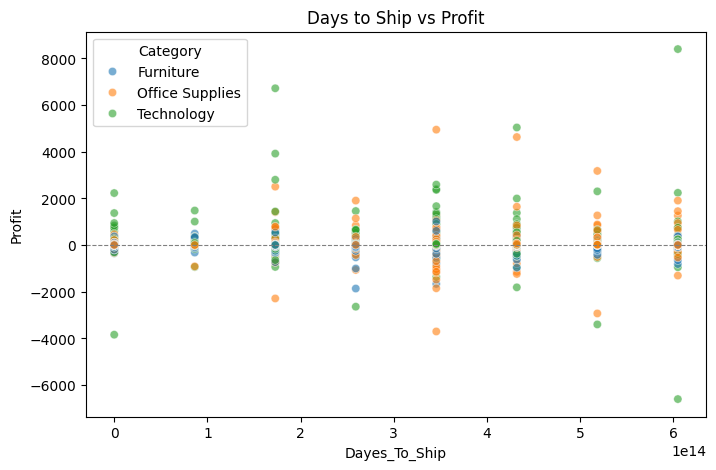

In [42]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='Dayes_To_Ship', y='Profit', hue='Category', alpha=0.6)
plt.title('Days to Ship vs Profit')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.show()

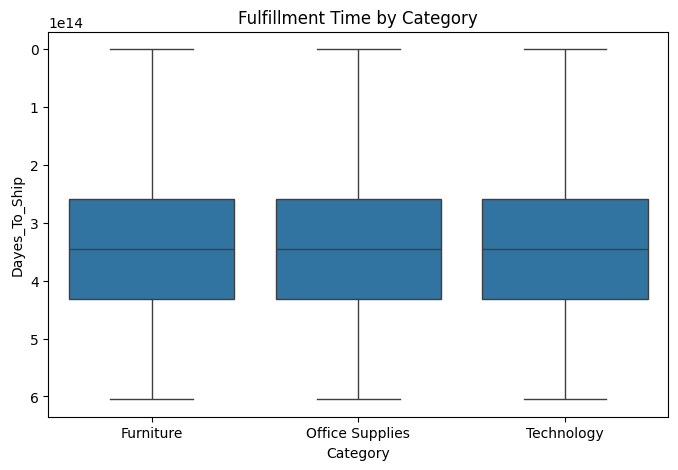

In [43]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Category', y='Dayes_To_Ship')
plt.title('Fulfillment Time by Category')
plt.show()